# Your own crystal

Every other notebook here opens on a file that came with Quantum ESPRESSO. This one starts
where you would: with a material you looked up, a lattice constant from a table, and a
pseudopotential you fetched.

The material is **diamond** -- two carbon atoms on the fcc lattice, $a = 3.567$ Å -- and
the point is the workflow rather than the crystal. Four things have to be decided before a
number from a plane-wave code means anything, and only the first two are physics:

1. the **structure**: which Bravais lattice, what lattice constant, where the atoms sit;
2. the **pseudopotential**, one file per element, which also fixes the functional;
3. the **cutoff**, which is not a property of the material but of the dataset, and has to be
   converged rather than guessed;
4. the **k-grid**, which is how finely the Brillouin zone is sampled.

| diamond, LDA | here | measured |
|---|---|---|
| total energy | **-22.85560171 Ry** | |
| indirect gap, off a band path | **4.1305 eV** | 5.47 eV |
| direct gap at $\Gamma$ | **5.5455 eV** | 7.3 eV |

Both gaps are the familiar semilocal underestimate, about 25% low, and notebook 24 is what
recovers most of it.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator
from pypresso.units import RY_TO_EV

INPUT = Path("../tests/data/qe/diamond.in")

diamond = Calculator.from_file(INPUT, pseudo_dir=Path("../tests/data/pseudo"),
                               announce=False)
print("diamond:   E = %.8f Ry" % diamond.get_scf().total_energy)

diamond:   E = -22.85560171 Ry


That is the whole of it: one file, one object, one call. The file is a `pw.x` input and
means exactly what it means to `pw.x`, so an input you already have runs here unchanged and
one written here runs there.

**Where a pseudopotential comes from.** Not from this repository, which ships only what its
tests need. The three places to look are Quantum ESPRESSO's own table at
`pseudopotentials.quantum-espresso.org`, the **PseudoDojo** set, and the **SSSP** library,
which curates datasets by accuracy and efficiency and publishes a recommended cutoff for
each element. Take the recommendation as a starting point and then measure it, which is what
the cell after next does. The file also decides the **functional**: the dataset used here was
generated with LDA, and running it under a different one is an inconsistency the package
warns about.

In [2]:
print(INPUT.read_text())

! Diamond -- the worked example of notebook 25, "your own crystal".
!
! Nothing about this file came from QE's test suite. It is what someone writes
! for a material they looked up, and every line of it is a decision:
!
!   ibrav = 2         the fcc Bravais lattice. Diamond is two carbon atoms in an
!                     fcc cell, which is the same lattice silicon is on.
!   celldm(1) = 6.74  the lattice parameter in bohr. Diamond's cubic lattice
!                     constant is 3.567 A = 6.74 bohr.
!   ecutwfc = 35      chosen by the convergence test the notebook runs, not by
!                     habit: the band gap is settled to 0.001 eV there, while the
!                     total energy is still 8e-4 Ry above its value at 50 Ry.
!                     Which of those matters is a property of the question.
!   ecutrho = 280     eight times ecutwfc, which is what an ultrasoft dataset
!                     needs where a norm-conserving one takes four.
!   nbnd = 8          four occupi

## The two convergence tests nobody may skip

A plane-wave basis is defined by one number, and a Brillouin-zone integral by one grid.
Neither is a property of the crystal, so neither has a right answer that can be looked up:
both have to be measured on the quantity being computed.

The input is a text file, so a sweep over either is a string substitution and a re-run.

In [3]:
base = INPUT.read_text()

def run(text):
    calc = Calculator.from_text(text, pseudo_dir=Path("../tests/data/pseudo"),
                                announce=False)
    levels = np.asarray(calc.get_scf().eigenvalues) * RY_TO_EV
    return (calc.scf_result.total_energy,
            float(levels[:, 4].min() - levels[:, 3].max()))

CUTOFFS = np.array([20.0, 25.0, 30.0, 35.0, 40.0, 50.0])
cutoff = np.array([run(base.replace("ecutwfc = 35.0, ecutrho = 280.0",
                                    "ecutwfc = %.1f, ecutrho = %.1f" % (e, 8 * e)))
                   for e in CUTOFFS])

GRIDS = np.array([2, 4, 6, 8])
grid = np.array([run(base.replace(" 6 6 6 0 0 0", " %d %d %d 0 0 0" % (n, n, n)))
                 for n in GRIDS])

print("at the file's 35 Ry:  %.1e Ry and %.4f eV from the 50 Ry run"
      % (abs(cutoff[3, 0] - cutoff[-1, 0]), abs(cutoff[3, 1] - cutoff[-1, 1])))
print("at its 6x6x6 grid:    %.1e Ry and %.4f eV from the 8x8x8 run"
      % (abs(grid[2, 0] - grid[-1, 0]), abs(grid[2, 1] - grid[-1, 1])))

at the file's 35 Ry:  7.7e-04 Ry and 0.0011 eV from the 50 Ry run
at its 6x6x6 grid:    6.1e-04 Ry and 0.0186 eV from the 8x8x8 run


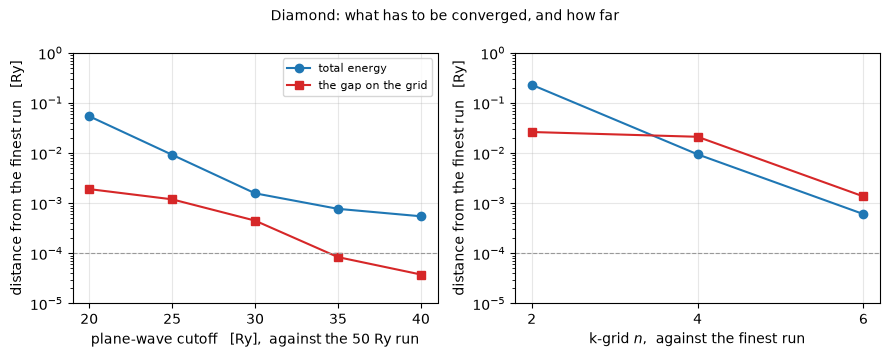

In [4]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.6))

left.semilogy(CUTOFFS[:-1], np.abs(cutoff[:-1, 0] - cutoff[-1, 0]), "o-",
              color="#1f77b4", label="total energy")
left.semilogy(CUTOFFS[:-1], np.abs(cutoff[:-1, 1] - cutoff[-1, 1]) / RY_TO_EV, "s-",
              color="#d62728", label="the gap on the grid")
left.set_xlabel("plane-wave cutoff   [Ry],  against the 50 Ry run")

right.semilogy(GRIDS[:-1], np.abs(grid[:-1, 0] - grid[-1, 0]), "o-", color="#1f77b4")
right.semilogy(GRIDS[:-1], np.abs(grid[:-1, 1] - grid[-1, 1]) / RY_TO_EV, "s-",
               color="#d62728")
right.set_xlabel("k-grid $n$,  against the finest run")
right.set_xticks(GRIDS[:-1])

for axis in (left, right):
    axis.axhline(1e-4, color="0.6", lw=0.8, ls="--")
    axis.set_ylabel("distance from the finest run   [Ry]")
    axis.grid(alpha=0.3)
    axis.set_ylim(1e-5, 1.0)
left.legend(fontsize=8)
fig.suptitle("Diamond: what has to be converged, and how far", fontsize=10)
fig.tight_layout()

The dashed line is 1e-4 Ry, about the accuracy an energy difference between two structures
needs. Three things the figure says, and the third is a trap.

**The cutoff converges from above and monotonically**, because a larger basis is
variationally better and can only lower the energy. Nothing forces the gap to do either, and
it does not: it is a difference of two eigenvalues converging at their own rates, and it is
inside 1e-4 Ry an order of magnitude before the total energy is. So a quantity can be
finished while the total energy is still moving -- **converge the quantity you are going to
quote**, not the total energy by reflex.

**The k-grid is where the cost is.** At the file's $6\times6\times6$ the total energy is
6e-4 Ry from the $8\times8\times8$ run, about what 40 Ry is from 50 Ry -- and closing that gap
means eight hundred k-points where the cutoff step means a slightly larger sphere. Diamond is
an insulator with smooth gapped bands, which is the *easy* case; a metal has a Fermi surface
cutting through them, the integrand is discontinuous, and the same accuracy costs an order of
magnitude more k-points again, which is what the smearing of notebook 06 exists to soften.

**And the red curve on the right is not a convergence failure.** What it plots is the
smallest gap *among the k-points of the run*, and diamond's conduction minimum sits about 85%
of the way from $\Gamma$ to X, which is on none of these grids. Changing the grid moves the
sampled points, so that number moves with them and would keep moving however fine the grid
got. **A band gap is read off a band structure, not off a self-consistent grid** -- which is
what the next cell does, and the two differ by 0.02 eV here.

## What you get once it is converged

Everything the rest of this set computes, off the same object.

indirect gap off the path   4.1305 eV   (measured 5.47)
direct gap at Gamma         5.5455 eV   (measured 7.3)


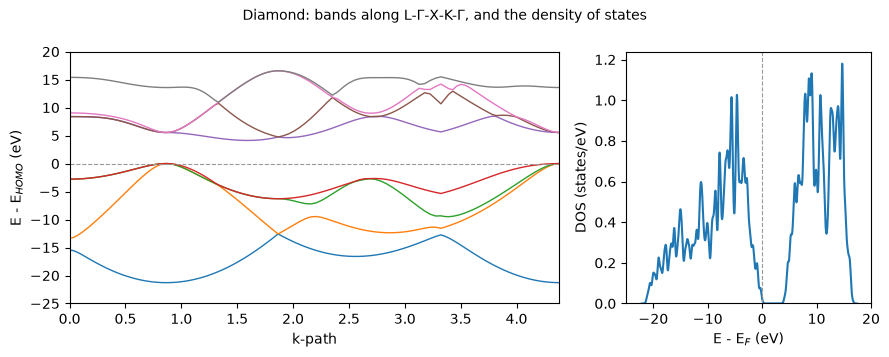

In [5]:
from pypresso.system.kpoints import KPoints

FCC = {"L": (.5, .5, .5), "G": (0., 0., 0.), "X": (0., 0., 1.), "K": (.75, .75, 0.)}
PATH = ["L", "G", "X", "K", "G"]
path = KPoints.band_path([FCC[p] for p in PATH], [30, 30, 30, 30, 1],
                         diamond.system.cell, crystal=False)

fig, (left, right) = plt.subplots(1, 2, figsize=(9.0, 3.6),
                                  gridspec_kw={"width_ratios": [2, 1]})
diamond.get_bands(kpoints=path).plot(ax=left)
diamond.get_dos(grid=(12, 12, 12), degauss=0.02).plot(ax=right)
left.set_ylim(-25, 20)
right.set_xlim(-25, 20)
fig.suptitle("Diamond: bands along L-$\Gamma$-X-K-$\Gamma$, and the density of states",
             fontsize=10)
fig.tight_layout()

levels = np.asarray(diamond.get_bands(kpoints=path).eigenvalues) * RY_TO_EV
print("indirect gap off the path   %.4f eV   (measured 5.47)"
      % (levels[:, 4].min() - levels[:, 3].max()))
print("direct gap at Gamma         %.4f eV   (measured 7.3)"
      % (levels[30, 4] - levels[30, 3]))

## What to check before believing a new crystal

- **The functional the dataset was generated with.** It is written in the file's header and
  is the functional the run uses unless `input_dft` overrides it. Overriding it is a real
  choice with a real cost, and the package says so rather than doing it silently.
- **The symmetry the code found.** A structure typed in by hand often has one atom a
  thousandth of a bohr off its site, which costs symmetry operations, k-points and time
  without changing an answer.
- **Whether the cell is big enough.** A slab or a molecule needs enough vacuum that its
  periodic images do not see each other, and that is its own convergence test.
- **The number of bands.** An insulator needs the occupied ones plus whatever is being
  looked at; a metal needs enough that the highest is well above the Fermi level.

---
This notebook has no `pw.x` reference and needs none: the number it produces is the
workflow. For the same quantities checked against Quantum ESPRESSO, notebook 02 is the
ground state and the bands, notebook 06 the density of states, and the index in
`notebooks/README.md` routes everything else by the property you want.